In [27]:
#This study book is about naive bayes classifier, which is a simple probabilistic classifier based on applying Bayes' theorem with strong (naive) independence assumptions between the features. 
#It is widely used in various applications such as spam filtering, sentiment analysis, and document classification. 
# The book covers the theory behind the naive bayes classifier, its implementation, and practical examples to help readers understand how to use it effectively in their projects.
#There are 3 different types of naive bayes classifiers: Gaussian, Multinomial, and Bernoulli.
#1. Gaussian Naive Bayes: This type of naive bayes classifier is used when the features are continuous and are assumed to follow a normal distribution. It calculates the mean and variance of the features for each class and uses these parameters to make predictions.
#2. Multinomial Naive Bayes: This type of naive bayes classifier is used when the features are discrete and represent counts or frequencies. It is commonly used in text classification tasks, where the features are the frequency of words in a document.
#3. Bernoulli Naive Bayes: This type of naive bayes classifier is used when the features are binary (0 or 1) and represent the presence or absence of a feature. It is also commonly used in text classification tasks, where the features indicate whether a word is present in a document or not.

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv("iris.csv")
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [31]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


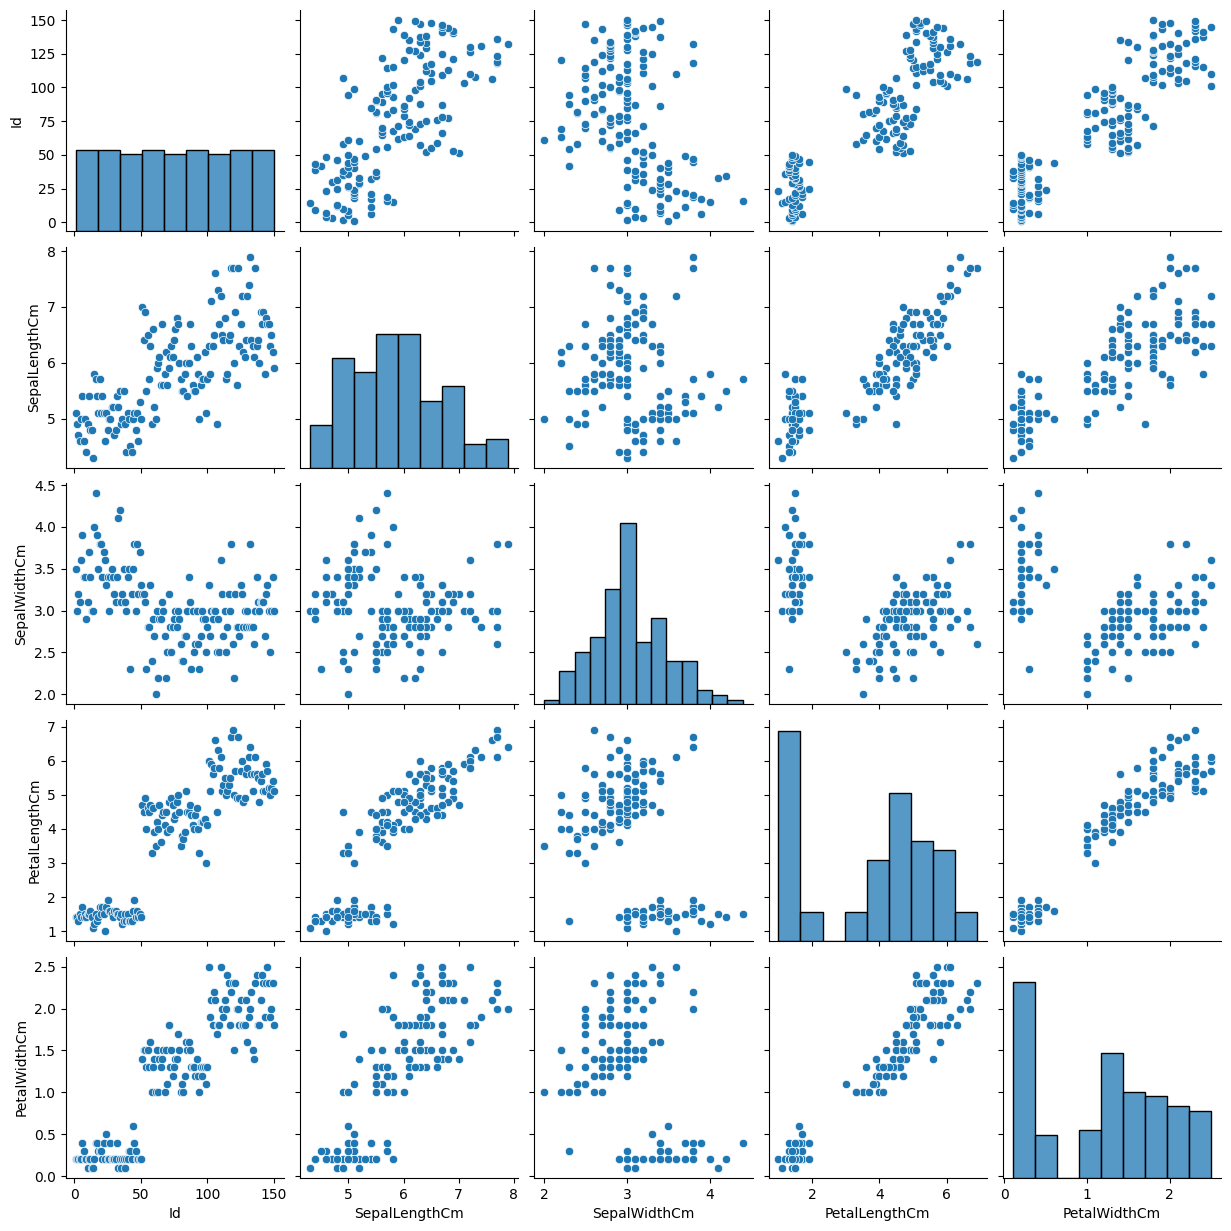

In [32]:
sns.pairplot(df)
plt.show()

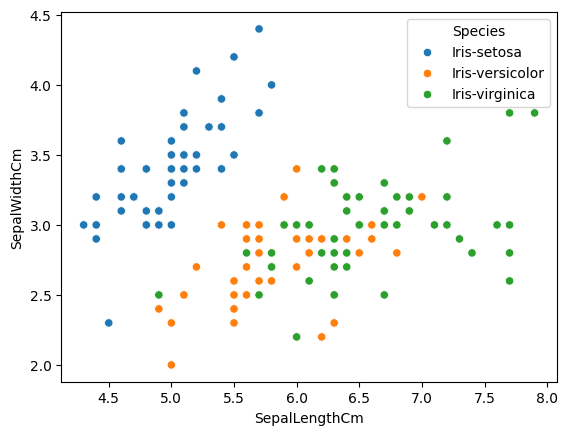

In [33]:
sns.scatterplot(x=df["SepalLengthCm"],y=df["SepalWidthCm"],hue=df["Species"])
plt.show()

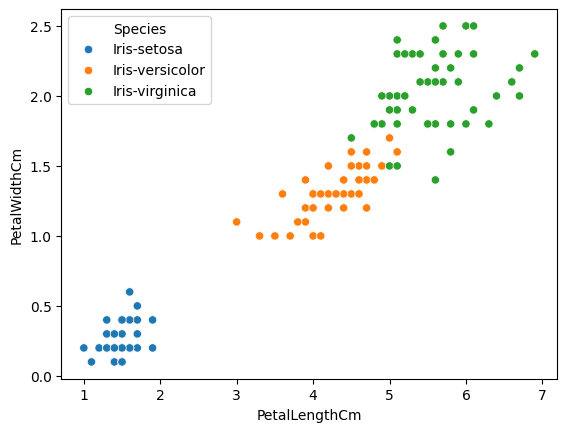

In [34]:
sns.scatterplot(x=df["PetalLengthCm"],y=df["PetalWidthCm"],hue=df["Species"])
plt.show()

In [35]:
df = df.drop("Id", axis=1)

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])
df.head(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [37]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [38]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
X=df.drop("Species", axis=1)
y=df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=34)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_pred, y_test)   
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_pred, y_test))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))

Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.88      1.00      0.94        15
           2       1.00      0.71      0.83         7

    accuracy                           0.95        38
   macro avg       0.96      0.90      0.92        38
weighted avg       0.95      0.95      0.94        38

Confusion Matrix:
 [[16  0  0]
 [ 0 15  0]
 [ 0  2  5]]


In [43]:
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_pred_lr, y_test)
print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression Classification Report:\n", classification_report(y_pred_lr, y_test))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_pred_lr, y_test))

Logistic Regression Accuracy: 1.0
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00         5

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Logistic Regression Confusion Matrix:
 [[16  0  0]
 [ 0 17  0]
 [ 0  0  5]]


In [44]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_pred_svm, y_test)
print("SVM Accuracy:", accuracy_svm)
print("SVM Classification Report:\n", classification_report(y_pred_svm, y_test))
print("SVM Confusion Matrix:\n", confusion_matrix(y_pred_svm, y_test))

SVM Accuracy: 1.0
SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00         5

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

SVM Confusion Matrix:
 [[16  0  0]
 [ 0 17  0]
 [ 0  0  5]]
